# AIBackends - receipt OCR and image understanding with local vision models

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/donvito/notebooks/blob/main/colab/AIBackends-vision-receipt-OCR.ipynb)

Extract structured receipt data and describe images with local vision-language models on
llama.cpp. aibackends downloads the GGUF **and** the matching `mmproj` projector for you.
Covers `examples/workflows/image_ocr_{gemma,lfm,qwen}.py` and
`image_understanding_{gemma,qwen}.py`:

| Model ref | GGUF repo |
| --- | --- |
| `GEMMA4_E2B` | `unsloth/gemma-4-E2B-it-GGUF` |
| `LFM25_VL_3B` | `LiquidAI/LFM2.5-VL-3B-GGUF` |
| `QWEN3_VL_4B` | `Qwen/Qwen3-VL-4B-Instruct-GGUF` |

**Runtime:** works on a CPU runtime; for faster inference pick *Runtime > Change runtime type > T4 GPU*. The device is detected automatically.

In [ ]:
import shutil
import subprocess

# Prebuilt llama-cpp-python wheels: CUDA 12.4 build on GPU runtimes, CPU build otherwise.
HAS_NVIDIA_GPU = (
    shutil.which("nvidia-smi") is not None
    and subprocess.run(["nvidia-smi"], capture_output=True).returncode == 0
)
LLAMA_WHEEL = (
    "https://github.com/abetlen/llama-cpp-python/releases/download/v0.3.35-cu124/llama_cpp_python-0.3.35-py3-none-manylinux_2_35_x86_64.whl"
    if HAS_NVIDIA_GPU
    else "https://github.com/abetlen/llama-cpp-python/releases/download/v0.3.35/llama_cpp_python-0.3.35-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl"
)
print("GPU runtime:", HAS_NVIDIA_GPU)
print("llama-cpp-python wheel:", LLAMA_WHEEL.rsplit("/", 2)[-2])

%pip install -q "{LLAMA_WHEEL}"
%pip install -q "aibackends[pdf]>=0.8.1" huggingface_hub

In [2]:
import shutil
import subprocess

import aibackends
import llama_cpp

# "gpu" offloads every layer to CUDA (n_gpu_layers=-1); "cpu" keeps everything on CPU.
HAS_NVIDIA_GPU = (
    shutil.which("nvidia-smi") is not None
    and subprocess.run(["nvidia-smi"], capture_output=True).returncode == 0
)
DEVICE = "gpu" if HAS_NVIDIA_GPU and llama_cpp.llama_supports_gpu_offload() else "cpu"

print("aibackends", aibackends.__version__)
print("llama-cpp-python", llama_cpp.__version__)
print("device:", DEVICE)

aibackends 0.8.1
llama-cpp-python 0.3.35
device: cpu


In [3]:
from pathlib import Path
from urllib.request import urlretrieve

DATA_URL = "https://raw.githubusercontent.com/donvito/aibackends/main/examples/data"
DATA_DIR = Path("aibackends_data")


def fetch(relative_path: str) -> Path:
    """Download a sample file from the aibackends examples once and return its path."""
    path = DATA_DIR / relative_path
    if not path.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        urlretrieve(f"{DATA_URL}/{relative_path}", path)
    return path

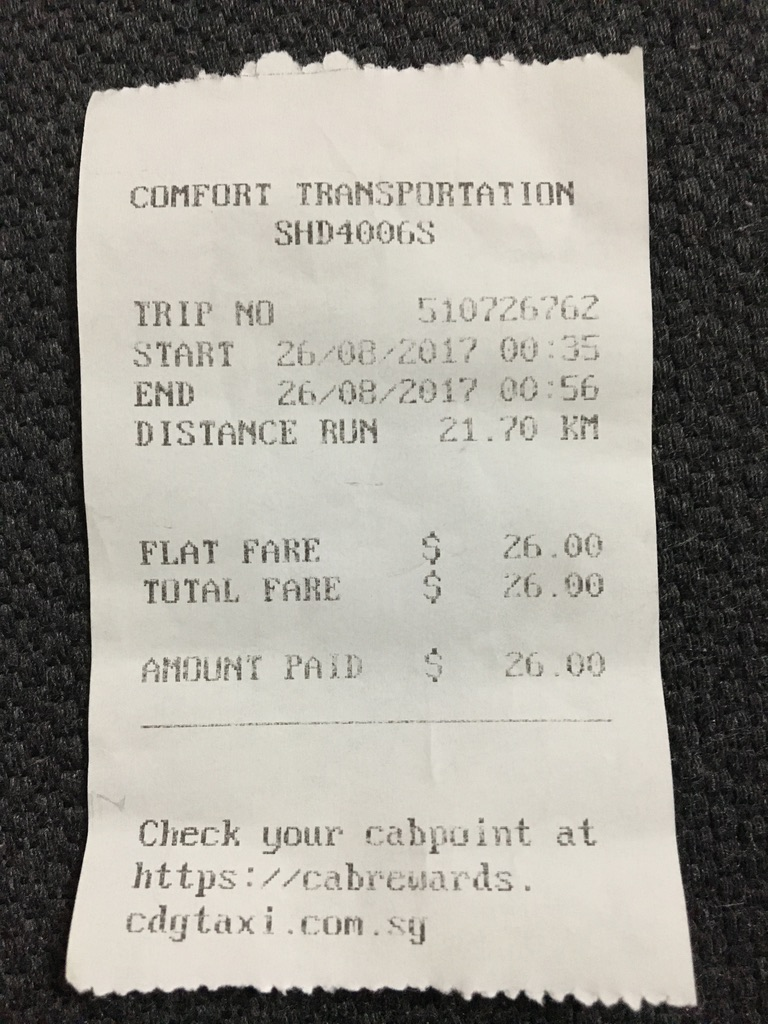

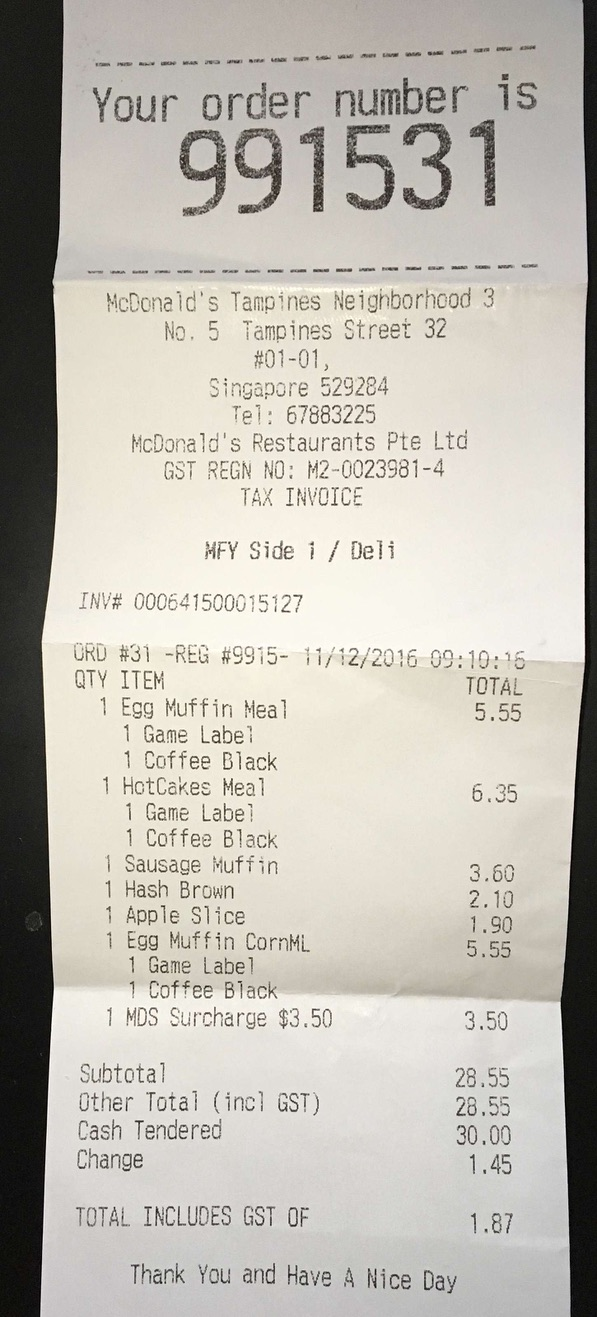

In [4]:
from IPython.display import Image, display

receipts = [fetch("images/receipt1.jpeg"), fetch("images/receipt2.jpeg")]
for path in receipts:
    display(Image(filename=str(path), width=260))

## 1. Define the workflows

`ImageIngestor` loads the image; `VisionExtractor` sends it with a prompt and validates the reply against a schema.

In [5]:
from pydantic import BaseModel, Field

from aibackends.models import GEMMA4_E2B, LFM25_VL_3B, QWEN3_VL_4B
from aibackends.runtimes import LLAMACPP
from aibackends.schemas.common import LineItem
from aibackends.steps.enrich import VisionExtractor
from aibackends.steps.ingest import ImageIngestor
from aibackends.workflows import Pipeline


class ReceiptResult(BaseModel):
    merchant: str | None = None
    receipt_date: str | None = None
    receipt_time: str | None = None
    receipt_number: str | None = None
    currency: str | None = None
    subtotal: float | None = None
    tax: float | None = None
    total: float | None = None
    payment_method: str | None = None
    line_items: list[LineItem] = Field(default_factory=list)


class ImageUnderstandingResult(BaseModel):
    description: str
    visible_text: str | None = None


class ReceiptWorkflow(Pipeline):
    steps = [
        ImageIngestor(),
        VisionExtractor(
            schema=ReceiptResult,
            prompt=(
                "Extract structured data from this receipt. Return JSON with these fields: "
                "merchant, receipt_date, receipt_time, receipt_number, currency, subtotal, "
                "tax, total, payment_method, and line_items. Use null for missing scalar "
                "fields and [] for missing line_items. Extract monetary values as numbers, "
                "not strings. Do not summarize or describe the image."
            ),
        ),
    ]


class ImageUnderstandingWorkflow(Pipeline):
    steps = [
        ImageIngestor(),
        VisionExtractor(
            schema=ImageUnderstandingResult,
            prompt=(
                "Describe the image. If there is readable text, copy it into visible_text. "
                "Keep the answer concise."
            ),
        ),
    ]

## 2. Receipt OCR with each model

Each model is a ~3 GB download; CPU runs take a few minutes per image.

In [6]:
import gc
import time

MODELS = {"Gemma 4 E2B": GEMMA4_E2B, "LFM2.5-VL-3B": LFM25_VL_3B, "Qwen3-VL-4B": QWEN3_VL_4B}
receipts_by_model = {}
for label, model in MODELS.items():
    workflow = ReceiptWorkflow(runtime=LLAMACPP, model=model, device=DEVICE, reuse_runtime=False)
    t = time.perf_counter()
    receipt = workflow.run(receipts[1])
    print(f"=== {label} ({time.perf_counter() - t:.0f}s)")
    print(receipt.model_dump_json(indent=2))
    receipts_by_model[label] = receipt
    del workflow
    gc.collect()

=== Gemma 4 E2B (79s)
{
  "merchant": "McDonald's Tampines Neighborhood 3 No. 5",
  "receipt_date": "11/12/2016",
  "receipt_time": "09:10:16",
  "receipt_number": "991531",
  "currency": "SGD",
  "subtotal": 991531.0,
  "tax": 187.0,
  "total": 10531.0,
  "payment_method": null,
  "line_items": [
    {
      "description": "Egg Muffin Meal",
      "quantity": 1.0,
      "unit_price": 0.0,
      "amount": 5.55
    },
    {
      "description": "Game Label",
      "quantity": 1.0,
      "unit_price": 0.0,
      "amount": 3.6
    },
    {
      "description": "Hot Cakes Meal",
      "quantity": 1.0,
      "unit_price": 0.0,
      "amount": 6.35
    },
    {
      "description": "Game Label",
      "quantity": 1.0,
      "unit_price": 0.0,
      "amount": 3.6
    },
    {
      "description": "Coffee Black",
      "quantity": 1.0,
      "unit_price": 0.0,
      "amount": 1.9
    },
    {
      "description": "Hash Brown",
      "quantity": 1.0,
      "unit_price": 2.1,
      "amount": 2.1

=== LFM2.5-VL-3B (339s)
{
  "merchant": "McDonald's Tampines Neighborhood 3",
  "receipt_date": "11/12/2016",
  "receipt_time": null,
  "receipt_number": "991531",
  "currency": "SGD",
  "subtotal": 28.55,
  "tax": 30.0,
  "total": 58.45,
  "payment_method": "Cash Tendered",
  "line_items": [
    {
      "description": "Egg Muffin Meal",
      "quantity": 1.0,
      "unit_price": 5.55,
      "amount": 5.55
    },
    {
      "description": "Game Label",
      "quantity": 1.0,
      "unit_price": null,
      "amount": null
    },
    {
      "description": "Coffee Black",
      "quantity": 1.0,
      "unit_price": null,
      "amount": null
    },
    {
      "description": "HotCakes Meal",
      "quantity": 1.0,
      "unit_price": 6.35,
      "amount": null
    },
    {
      "description": "Game Label",
      "quantity": 1.0,
      "unit_price": null,
      "amount": null
    },
    {
      "description": "Coffee Black",
      "quantity": 1.0,
      "unit_price": null,
      "amount"

=== Qwen3-VL-4B (112s)
{
  "merchant": "McDonald's Tampines Neighborhood 3",
  "receipt_date": "11/12/2016",
  "receipt_time": "09:10:16",
  "receipt_number": "991531",
  "currency": "SGD",
  "subtotal": 28.55,
  "tax": 1.87,
  "total": 30.42,
  "payment_method": "Cash",
  "line_items": [
    {
      "description": "1 Egg Muffin Meal",
      "quantity": 1.0,
      "unit_price": 5.55,
      "amount": 5.55
    },
    {
      "description": "1 Game Label",
      "quantity": 1.0,
      "unit_price": 0.0,
      "amount": 0.0
    },
    {
      "description": "1 Coffee Black",
      "quantity": 1.0,
      "unit_price": 0.0,
      "amount": 0.0
    },
    {
      "description": "1 HotCakes Meal",
      "quantity": 1.0,
      "unit_price": 6.35,
      "amount": 6.35
    },
    {
      "description": "1 Game Label",
      "quantity": 1.0,
      "unit_price": 0.0,
      "amount": 0.0
    },
    {
      "description": "1 Coffee Black",
      "quantity": 1.0,
      "unit_price": 0.0,
      "amount

### Compare the headline fields

In [7]:
import pandas as pd

pd.DataFrame(
    {label: r.model_dump(exclude={"line_items"}) | {"line_items": len(r.line_items)}
     for label, r in receipts_by_model.items()}
)

,Gemma 4 E2B,LFM2.5-VL-3B,Qwen3-VL-4B
merchant,McDonald's Tampines Neighborhood 3 No. 5,McDonald's Tampines Neighborhood 3,McDonald's Tampines Neighborhood 3
receipt_date,11/12/2016,11/12/2016,11/12/2016
receipt_time,09:10:16,None,09:10:16
receipt_number,991531,991531,991531
currency,SGD,SGD,SGD
subtotal,991531.0,28.55,28.55
tax,187.0,30.0,1.87
total,10531.0,58.45,30.42
payment_method,None,Cash Tendered,Cash
line_items,10,13,13


## 3. Image understanding

Same ingestion step, a free-form description schema.

In [8]:
for label in ["Gemma 4 E2B", "Qwen3-VL-4B"]:
    workflow = ImageUnderstandingWorkflow(
        runtime=LLAMACPP, model=MODELS[label], device=DEVICE, reuse_runtime=False
    )
    result = workflow.run(receipts[0])
    print(f"=== {label}")
    print(result.model_dump_json(indent=2))
    del workflow
    gc.collect()

=== Gemma 4 E2B
{
  "description": "A receipt detailing a transport charge.",
  "visible_text": "COMFORT TRANSPORT SHD400GS TRIP NO 510726762 START 26/08/2017 00:35 END 26/08/2017 00:56 DISTANCE RUN 21.70 KM FLAT FARE $ 26.00 TOTAL FARE $ 26.90 AMOUNT PAID $ 26.00 Check your cabpoint at https://cabrewards.cdgtaxi.com.sy"
}


=== Qwen3-VL-4B
{
  "description": "A receipt from Comfort Transportation showing a trip details and fare information.",
  "visible_text": "COMFORT TRANSPORTATION\nSHD4006S\nTRIP NO 510726762\nSTART 26/08/2017 00:35\nEND 26/08/2017 00:56\nDISTANCE RUN 21.70 KM\nFLAT FARE $ 26.00\nTOTAL FARE $ 26.00\nAMOUNT PAID $ 26.00\nCheck your cabpoint at https://cabrewards.\ncdgtaxi.com.sg"
}
